In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

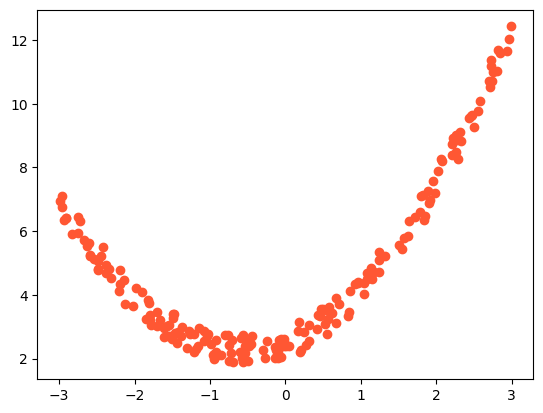

In [25]:
x = 6*np.random.rand(200,1)-3
y = 0.8*x**2+0.9*x+2 + np.random.rand(200,1)

plt.plot(x,y,'c. ')
plt.plot(x, y, color='#FF5733', marker='o', linestyle='None')

R2 Score: 0.36563042360644626


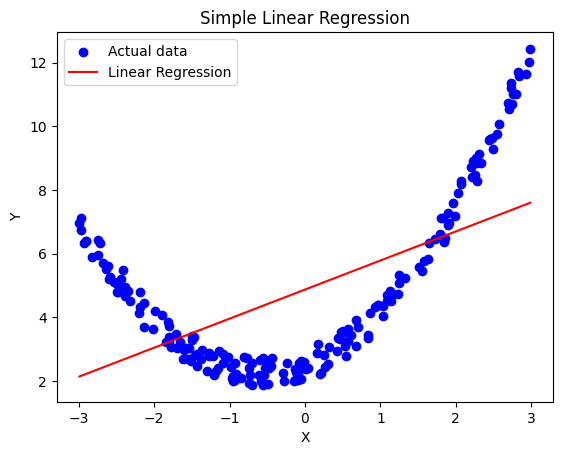

In [33]:

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("R2 Score:", r2_score(y_test, y_pred))

plt.scatter(x, y, color="blue", label="Actual data")

x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color="red", label="Linear Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

r-Square for polynomial regression is:  0.9858823593563624


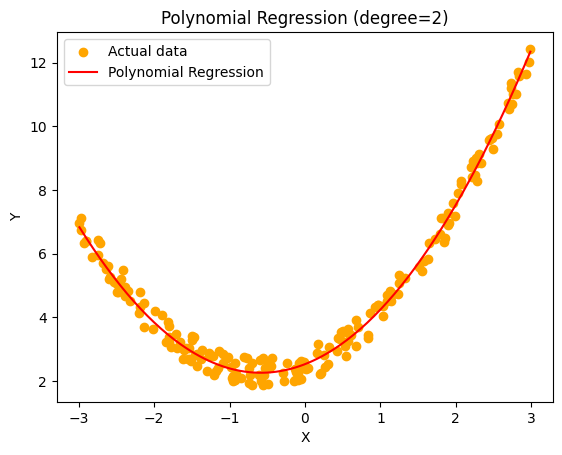

In [46]:
poly = PolynomialFeatures(degree=2)
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

model = LinearRegression()
model.fit(x_train_trans , y_train)
y_pred = model.predict(x_test_trans)
print("r-Square for polynomial regression is: ", r2_score(y_test,y_pred))

plt.scatter(x, y, color="orange", label="Actual data")
x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
x_line_trans = poly.transform(x_line)
y_line = model.predict(x_line_trans)
plt.plot(x_line, y_line, color="red", label="Polynomial Regression")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression (degree=2)")
plt.legend()
plt.show()

R - square for polynomial regression is:  0.9858823593563624


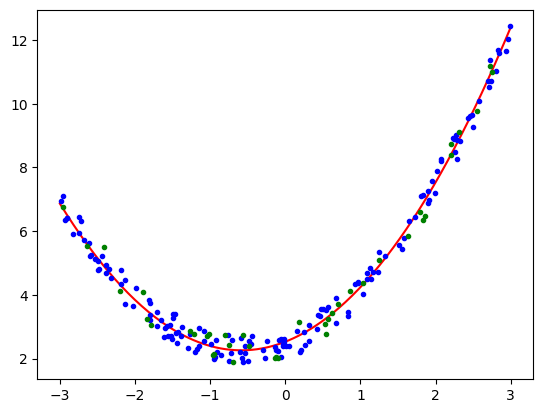

In [ ]:
model = LinearRegression()
model.fit(x_train_trans, y_train)

y_pred = model.predict(x_test_trans)
print("R - square for polynomial regression is: ",r2_score(y_test,y_pred))

x_new = np.linspace(-3,3,200).reshape(200,1)
xnew_poly = poly.transform(x_new)
y_new = model.predict(xnew_poly) 

plt.plot(x_new, y_new, 'r-')
plt.plot(x_train, y_train, 'b. ')
plt.plot(x_test,y_test,'g. ')
plt.show()



R-Square: 0.9162082221443942


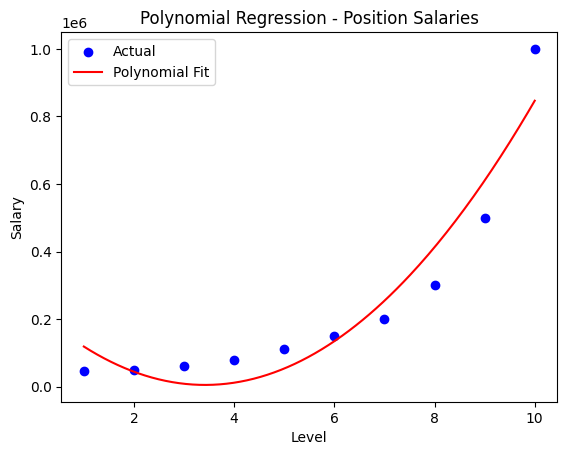

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Load data
df = pd.read_csv('Position_Salaries.csv')
x = df[['Level']].values   # feature (Level)
y = df['Salary'].values     # target (Salary)

# Polynomial transformation
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

# Train model
model = LinearRegression()
model.fit(x_poly, y)

# Predict and R² score
y_pred = model.predict(x_poly)
print("R-Square:", r2_score(y, y_pred))

# Plot
x_line = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_line = model.predict(poly.transform(x_line))

plt.scatter(x, y, color='blue', label='Actual')
plt.plot(x_line, y_line, color='red', label='Polynomial Fit')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Polynomial Regression - Position Salaries')
plt.legend()
plt.show()
